In [ ]:
import numpy as np
import pandas as pd
from datetime import date
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, accuracy_score, roc_auc_score
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Preprocessing

### nflverse Dataset (1999-2025)

In [ ]:
nflverse_df = pd.read_csv('/content/drive/My Drive/Data/games.csv') # replace with name of your file

nflverse_df.head()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,...,NaN,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,...,12.0,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,...,12.0,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,...,10.0,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,...,NaN,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome


### Kaggle Dataset (2017-2025) up until 2025-11-10

In [ ]:
# Not currently used in the models

kaggle_df = pd.read_csv('/content/drive/My Drive/Data/2017-2025_scores.csv') # replace with name of file

kaggle_df.head()

,Season,Week,GameStatus,Day,Date,AwayTeam,AwayRecord,AwayScore,AwayWin,HomeTeam,HomeRecord,HomeScore,HomeWin,AwaySeeding,HomeSeeding,PostSeason
0,2017,Hall Of Fame,FINAL,THU,08/03,Cardinals,0-1,18.0,0.0,Cowboys,1-0,20.0,1.0,NaN,NaN,0
1,2017,Preseason Week 1,FINAL,WED,08/09,Texans,0-1,17.0,0.0,Panthers,1-0,27.0,1.0,NaN,NaN,0
2,2017,Preseason Week 1,FINAL,THU,08/10,Vikings,1-0,17.0,1.0,Bills,0-1,10.0,0.0,NaN,NaN,0
3,2017,Preseason Week 1,FINAL,THU,08/10,Falcons,0-1,20.0,0.0,Dolphins,1-0,23.0,1.0,NaN,NaN,0
4,2017,Preseason Week 1,FINAL,THU,08/10,Redskins,0-1,3.0,0.0,Ravens,1-0,23.0,1.0,NaN,NaN,0


##Cleaning

### NFL Verse Cleaning

#### Add label

In [ ]:
# Drop ties (result == 0)
nflverse_df = nflverse_df[nflverse_df["result"] != 0].copy()

# Create label: 1 = home win, 0 = away win
nflverse_df["label"] = (nflverse_df["result"] > 0).astype(int)

nflverse_df.head()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,...,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium,label
0,1999_01_MIN_ATL,1999,REG,1,1999-09-12,Sunday,NaN,MIN,17.0,ATL,...,00-0003761,00-0002876,Randall Cunningham,Chris Chandler,Dennis Green,Dan Reeves,Gerry Austin,ATL00,Georgia Dome,0
1,1999_01_KC_CHI,1999,REG,1,1999-09-12,Sunday,NaN,KC,17.0,CHI,...,00-0006300,00-0010560,Elvis Grbac,Shane Matthews,Gunther Cunningham,Dick Jauron,Phil Luckett,CHI98,Soldier Field,1
2,1999_01_PIT_CLE,1999,REG,1,1999-09-12,Sunday,NaN,PIT,43.0,CLE,...,00-0015700,00-0004230,Kordell Stewart,Ty Detmer,Bill Cowher,Chris Palmer,Bob McElwee,CLE00,Cleveland Browns Stadium,0
3,1999_01_OAK_GB,1999,REG,1,1999-09-12,Sunday,NaN,OAK,24.0,GB,...,00-0005741,00-0005106,Rich Gannon,Brett Favre,Jon Gruden,Ray Rhodes,Tony Corrente,GNB00,Lambeau Field,1
4,1999_01_BUF_IND,1999,REG,1,1999-09-12,Sunday,NaN,BUF,14.0,IND,...,00-0005363,00-0010346,Doug Flutie,Peyton Manning,Wade Phillips,Jim Mora,Ron Blum,IND99,RCA Dome,1


#### Drop Leakage, Duplicate, and Irrelevant Features

In [ ]:
leak_or_id_cols = [
    'game_id', 'result', 'total', 'overtime',
    'old_game_id', 'gsis', 'nfl_detail_id', 'pfr', 'pff', 'espn', 'ftn', 'temp', 'wind'
    , 'away_score', 'home_score', 'spread_line', 'away_spread_odds',
       'home_spread_odds', 'total_line', 'under_odds', 'over_odds', 'away_moneyline', 'home_moneyline'
]

duplicate_cols = ['stadium','away_qb_name', 'home_qb_name']

irrelevant_cols = ['location', 'gametime', 'weekday', 'surface']

nflverse_df = nflverse_df.drop(columns=leak_or_id_cols, axis=1)
nflverse_df = nflverse_df.drop(columns=duplicate_cols, axis=1)
nflverse_df = nflverse_df.drop(columns=irrelevant_cols, axis=1)

nflverse_clean_df = nflverse_df.dropna()
nflverse_clean_df.head()

nflverse_clean_df.columns

Index(['season', 'game_type', 'week', 'gameday', 'away_team', 'home_team',
       'away_rest', 'home_rest', 'div_game', 'roof', 'away_qb_id',
       'home_qb_id', 'away_coach', 'home_coach', 'referee', 'stadium_id',
       'label'],
      dtype='object')

### Kaggle Cleaning

In [ ]:
import pandas as pd

# Rename columns so they match nflverse naming style.
kaggle_df = kaggle_df.rename(columns={
    "Season": "season",
    "Date":   "date",
    "AwayTeam": "away_team_name",
    "HomeTeam": "home_team_name",
    "AwayScore": "away_score_old",
    "HomeScore": "home_score_old",
})
kaggle_df.head()

,season,Week,GameStatus,Day,date,away_team_name,AwayRecord,away_score_old,AwayWin,home_team_name,HomeRecord,home_score_old,HomeWin,AwaySeeding,HomeSeeding,PostSeason
0,2017,Hall Of Fame,FINAL,THU,08/03,Cardinals,0-1,18.0,0.0,Cowboys,1-0,20.0,1.0,NaN,NaN,0
1,2017,Preseason Week 1,FINAL,WED,08/09,Texans,0-1,17.0,0.0,Panthers,1-0,27.0,1.0,NaN,NaN,0
2,2017,Preseason Week 1,FINAL,THU,08/10,Vikings,1-0,17.0,1.0,Bills,0-1,10.0,0.0,NaN,NaN,0
3,2017,Preseason Week 1,FINAL,THU,08/10,Falcons,0-1,20.0,0.0,Dolphins,1-0,23.0,1.0,NaN,NaN,0
4,2017,Preseason Week 1,FINAL,THU,08/10,Redskins,0-1,3.0,0.0,Ravens,1-0,23.0,1.0,NaN,NaN,0


In [ ]:
import numpy as np
import pandas as pd

# make sure "date" is string
kaggle_df["date"] = kaggle_df["date"].astype(str).str.strip()

# mask: rows that look like MM/DD
date_mask = kaggle_df["date"].str.contains("/", na=False)

# create empty month/day columns as floats (to allow NaN)
kaggle_df["month"] = np.nan
kaggle_df["day"] = np.nan

# split only on valid date rows
month_day = kaggle_df.loc[date_mask, "date"].str.split("/", expand=True)

kaggle_df.loc[date_mask, "month"] = month_day[0].astype(int)
kaggle_df.loc[date_mask, "day"] = month_day[1].astype(int)

# now compute the correct year for those rows
kaggle_df["year"] = np.nan
kaggle_df.loc[date_mask, "year"] = kaggle_df.loc[date_mask].apply(
    lambda row: row["season"] if row["month"] >= 8 else row["season"] + 1,
    axis=1
)

# build gameday only for valid date rows
kaggle_df["gameday"] = pd.NaT
kaggle_df.loc[date_mask, "gameday"] = pd.to_datetime(
    kaggle_df.loc[date_mask, "year"].astype(int).astype(str)
    + "-"
    + kaggle_df.loc[date_mask, "month"].astype(int).astype(str).str.zfill(2)
    + "-"
    + kaggle_df.loc[date_mask, "day"].astype(int).astype(str).str.zfill(2)
)


kaggle_df.head()

,season,Week,GameStatus,Day,date,away_team_name,AwayRecord,away_score_old,AwayWin,home_team_name,HomeRecord,home_score_old,HomeWin,AwaySeeding,HomeSeeding,PostSeason,month,day,year,gameday
0,2017,Hall Of Fame,FINAL,THU,08/03,Cardinals,0-1,18.0,0.0,Cowboys,1-0,20.0,1.0,NaN,NaN,0,8.0,3.0,2017.0,2017-08-03
1,2017,Preseason Week 1,FINAL,WED,08/09,Texans,0-1,17.0,0.0,Panthers,1-0,27.0,1.0,NaN,NaN,0,8.0,9.0,2017.0,2017-08-09
2,2017,Preseason Week 1,FINAL,THU,08/10,Vikings,1-0,17.0,1.0,Bills,0-1,10.0,0.0,NaN,NaN,0,8.0,10.0,2017.0,2017-08-10
3,2017,Preseason Week 1,FINAL,THU,08/10,Falcons,0-1,20.0,0.0,Dolphins,1-0,23.0,1.0,NaN,NaN,0,8.0,10.0,2017.0,2017-08-10
4,2017,Preseason Week 1,FINAL,THU,08/10,Redskins,0-1,3.0,0.0,Ravens,1-0,23.0,1.0,NaN,NaN,0,8.0,10.0,2017.0,2017-08-10


In [ ]:
# Base map for stable teams 2017–2025
base_team_map = {
    "Cardinals": "ARI",
    "Falcons": "ATL",
    "Ravens": "BAL",
    "Bills": "BUF",
    "Panthers": "CAR",
    "Bears": "CHI",
    "Bengals": "CIN",
    "Browns": "CLE",
    "Cowboys": "DAL",
    "Broncos": "DEN",
    "Lions": "DET",
    "Packers": "GB",
    "Texans": "HOU",
    "Colts": "IND",
    "Jaguars": "JAX",
    "Chiefs": "KC",
    "Dolphins": "MIA",
    "Vikings": "MIN",
    "Patriots": "NE",
    "Saints": "NO",
    "Giants": "NYG",
    "Jets": "NYJ",
    "Eagles": "PHI",
    "Steelers": "PIT",
    "Seahawks": "SEA",
    "49ers": "SF",
    "Buccaneers": "TB",
    "Titans": "TEN",
    "Rams": "LA",   # always LA in 2017–2025
}

def team_to_abbr(name: str, season: int) -> str:
    name = str(name).strip()

    # Washington franchise
    if name in ["Redskins", "Football Team", "Washington Football Team", "Commanders", "Washington"]:
        return "WAS"

    # Raiders: OAK -> LV (in 2020)
    if name == "Raiders":
        return "LV" if season >= 2020 else "OAK"

    # Chargers: SD -> LAC (in 2017)
    if name == "Chargers":
        return "LAC"

    # Rams: always LA for your timeframe
    if name == "Rams":
        return "LA"

    # Otherwise stable name
    return base_team_map.get(name)



In [ ]:
# make sure season is int
kaggle_df["season"] = kaggle_df["season"].astype(int)

kaggle_df["away_team"] = kaggle_df.apply(
    lambda row: team_to_abbr(row["away_team_name"], row["season"]),
    axis=1
)

kaggle_df["home_team"] = kaggle_df.apply(
    lambda row: team_to_abbr(row["home_team_name"], row["season"]),
    axis=1
)


kaggle_df.head()

,season,Week,GameStatus,Day,date,away_team_name,AwayRecord,away_score_old,AwayWin,home_team_name,...,HomeWin,AwaySeeding,HomeSeeding,PostSeason,month,day,year,gameday,away_team,home_team
0,2017,Hall Of Fame,FINAL,THU,08/03,Cardinals,0-1,18.0,0.0,Cowboys,...,1.0,NaN,NaN,0,8.0,3.0,2017.0,2017-08-03,ARI,DAL
1,2017,Preseason Week 1,FINAL,WED,08/09,Texans,0-1,17.0,0.0,Panthers,...,1.0,NaN,NaN,0,8.0,9.0,2017.0,2017-08-09,HOU,CAR
2,2017,Preseason Week 1,FINAL,THU,08/10,Vikings,1-0,17.0,1.0,Bills,...,0.0,NaN,NaN,0,8.0,10.0,2017.0,2017-08-10,MIN,BUF
3,2017,Preseason Week 1,FINAL,THU,08/10,Falcons,0-1,20.0,0.0,Dolphins,...,1.0,NaN,NaN,0,8.0,10.0,2017.0,2017-08-10,ATL,MIA
4,2017,Preseason Week 1,FINAL,THU,08/10,Redskins,0-1,3.0,0.0,Ravens,...,1.0,NaN,NaN,0,8.0,10.0,2017.0,2017-08-10,WAS,BAL


In [ ]:
leak_or_id_cols = [
    'AwayWin', 'HomeWin', 'home_score_old', 'away_score_old'
]

duplicate_cols = ["away_team_name", "home_team_name"]

irrelevant_cols = ['month', 'day', 'year', 'HomeSeeding', 'AwaySeeding']

kaggle_df = kaggle_df.drop(columns=leak_or_id_cols, axis=1)
kaggle_df = kaggle_df.drop(columns=duplicate_cols, axis=1)
kaggle_df = kaggle_df.drop(columns=irrelevant_cols, axis=1)

kaggle_clean_df = kaggle_df.dropna()
kaggle_clean_df.head()

kaggle_clean_df.columns

Index(['season', 'Week', 'GameStatus', 'Day', 'date', 'AwayRecord',
       'HomeRecord', 'PostSeason', 'gameday', 'away_team', 'home_team'],
      dtype='object')

## Merging Datasets

In [ ]:
print(kaggle_clean_df.columns)
print(nflverse_clean_df.columns)


Index(['season', 'Week', 'GameStatus', 'Day', 'date', 'AwayRecord',
       'HomeRecord', 'PostSeason', 'gameday', 'away_team', 'home_team'],
      dtype='object')
Index(['season', 'game_type', 'week', 'gameday', 'away_team', 'home_team',
       'away_rest', 'home_rest', 'div_game', 'roof', 'away_qb_id',
       'home_qb_id', 'away_coach', 'home_coach', 'referee', 'stadium_id',
       'label'],
      dtype='object')


In [ ]:
nflverse_df["gameday"] = pd.to_datetime(nflverse_df["gameday"])
kaggle_df["gameday"] = pd.to_datetime(kaggle_df["gameday"])

In [ ]:
merged_df = nflverse_df.merge(
    kaggle_df[
        [
            "season", 'gameday', "away_team", "home_team",
            "Week", "GameStatus", "Day",
            "AwayRecord",
            "HomeRecord",
            "PostSeason"
        ]
    ],
    on=["gameday", "away_team", "home_team"],
    how="left",
    suffixes=("", "_kaggle")
)

merged_df.head()

,season,game_type,week,gameday,away_team,home_team,away_rest,home_rest,div_game,roof,...,referee,stadium_id,label,season_kaggle,Week,GameStatus,Day,AwayRecord,HomeRecord,PostSeason
0,1999,REG,1,1999-09-12,MIN,ATL,7,7,0,dome,...,Gerry Austin,ATL00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999,REG,1,1999-09-12,KC,CHI,7,7,0,outdoors,...,Phil Luckett,CHI98,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1999,REG,1,1999-09-12,PIT,CLE,7,7,1,outdoors,...,Bob McElwee,CLE00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1999,REG,1,1999-09-12,OAK,GB,7,7,0,outdoors,...,Tony Corrente,GNB00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1999,REG,1,1999-09-12,BUF,IND,7,7,1,dome,...,Ron Blum,IND99,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import numpy as np
import pandas as pd

# Make sure games are sorted by season then date
merged_df = merged_df.sort_values(["season", "gameday"]).reset_index(drop=True)

# Initialize columns for PRE-GAME record
merged_df["away_wins"] = 0
merged_df["away_losses"] = 0
merged_df["home_wins"] = 0
merged_df["home_losses"] = 0

# Dictionary: (season, team) -> (wins, losses) SO FAR in that season
team_record = {}
current_season = None

for idx, row in merged_df.iterrows():
    season = row["season"]
    away = row["away_team"]
    home = row["home_team"]

    # Reset records when we move to a new season
    if season != current_season:
        team_record = {}
        current_season = season

    # Get PRE-GAME records (default 0–0 if first game this season)
    away_w, away_l = team_record.get((season, away), (0, 0))
    home_w, home_l = team_record.get((season, home), (0, 0))

    # Store PRE-GAME record into dataframe
    merged_df.at[idx, "away_wins"] = away_w
    merged_df.at[idx, "away_losses"] = away_l
    merged_df.at[idx, "home_wins"] = home_w
    merged_df.at[idx, "home_losses"] = home_l

    # Now update records AFTER the game based on the label
    if row["label"] == 1:      # home wins
        home_w += 1
        away_l += 1
    else:                      # away wins
        away_w += 1
        home_l += 1

    team_record[(season, away)] = (away_w, away_l)
    team_record[(season, home)] = (home_w, home_l)

# Games played & win% AT THAT TIME (pre-game)
merged_df["away_games_played"] = merged_df["away_wins"] + merged_df["away_losses"]
merged_df["home_games_played"] = merged_df["home_wins"] + merged_df["home_losses"]

merged_df["away_win_pct"] = np.where(
    merged_df["away_games_played"] > 0,
    merged_df["away_wins"] / merged_df["away_games_played"],
    0.0
)

merged_df["home_win_pct"] = np.where(
    merged_df["home_games_played"] > 0,
    merged_df["home_wins"] / merged_df["home_games_played"],
    0.0
)




In [ ]:
merged_df.columns

Index(['season', 'game_type', 'week', 'gameday', 'away_team', 'home_team',
       'away_rest', 'home_rest', 'div_game', 'roof', 'away_qb_id',
       'home_qb_id', 'away_coach', 'home_coach', 'referee', 'stadium_id',
       'label', 'season_kaggle', 'Week', 'GameStatus', 'Day', 'AwayRecord',
       'HomeRecord', 'PostSeason', 'away_wins', 'away_losses', 'home_wins',
       'home_losses', 'away_games_played', 'home_games_played', 'away_win_pct',
       'home_win_pct'],
      dtype='object')

In [ ]:
merged_df = merged_df[(merged_df["season"] >= 2017) & (merged_df["season"] <= 2024)]


merged_df = merged_df.drop(columns=["season_kaggle", "Week", "GameStatus", "Day", "home_games_played", "away_games_played"], axis=1)
merged_df = merged_df.drop(columns=["AwayRecord", "HomeRecord"], axis=1)

merged_clean_df = merged_df

merged_clean_df.head()


,season,game_type,week,gameday,away_team,home_team,away_rest,home_rest,div_game,roof,...,referee,stadium_id,label,PostSeason,away_wins,away_losses,home_wins,home_losses,away_win_pct,home_win_pct
4775,2017,REG,1,2017-09-07,KC,NE,7,7,0,outdoors,...,Bill Vinovich,BOS00,0,0.0,0,0,0,0,0.0,0.0
4776,2017,REG,1,2017-09-10,NYJ,BUF,7,7,1,outdoors,...,John Hussey,BUF00,1,0.0,0,0,0,0,0.0,0.0
4777,2017,REG,1,2017-09-10,ATL,CHI,7,7,0,outdoors,...,Jeff Triplette,CHI98,0,0.0,0,0,0,0,0.0,0.0
4778,2017,REG,1,2017-09-10,BAL,CIN,7,7,1,outdoors,...,Walt Coleman,CIN00,0,0.0,0,0,0,0,0.0,0.0
4779,2017,REG,1,2017-09-10,PIT,CLE,7,7,1,outdoors,...,Craig Wrolstad,CLE00,0,0.0,0,0,0,0,0.0,0.0


In [ ]:
X = merged_clean_df.drop(columns=['label'], axis=1)
y = merged_clean_df['label']


numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

all_cat = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


high_card_cols = [
    "away_team", "home_team",
    "away_qb_id", "home_qb_id",
    "away_coach", "home_coach",
    "referee", "stadium_id"
]

# Only keep those actually in X
freq_features = [c for c in high_card_cols if c in all_cat]


# Remaining categorical → OneHot
onehot_features = [c for c in all_cat if c not in freq_features]


print("Numeric features:", numeric_features)
print("One-hot categorical features:", onehot_features)
print("Frequency-encoded features:", freq_features)


Numeric features: ['season', 'week', 'away_rest', 'home_rest', 'div_game', 'PostSeason', 'away_wins', 'away_losses', 'home_wins', 'home_losses', 'away_win_pct', 'home_win_pct']
One-hot categorical features: ['game_type', 'roof']
Frequency-encoded features: ['away_team', 'home_team', 'away_qb_id', 'home_qb_id', 'away_coach', 'home_coach', 'referee', 'stadium_id']


## Preprocessor

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
        self.freq_maps = {}

    def fit(self, X, y=None):
        X = X.copy()
        for col in self.columns:
            freq = X[col].value_counts(normalize=True)
            self.freq_maps[col] = freq
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X


In [ ]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
freq_transformer = FrequencyEncoder(columns=freq_features)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, onehot_features),
        ('freq', freq_transformer, freq_features)
    ]
)

### Train/Test Split

In [ ]:
train_df = merged_clean_df[(merged_clean_df["season"] >= 2017) &
                       (merged_clean_df["season"] <= 2023)]

test_df  = merged_clean_df[merged_clean_df["season"] == 2024]
X_train = train_df.drop(columns=['label'], axis=1)
y_train = train_df['label']
X_test = test_df.drop(columns=['label'], axis=1)
y_test = test_df['label']

X_train.columns

Index(['season', 'game_type', 'week', 'gameday', 'away_team', 'home_team',
       'away_rest', 'home_rest', 'div_game', 'roof', 'away_qb_id',
       'home_qb_id', 'away_coach', 'home_coach', 'referee', 'stadium_id',
       'PostSeason', 'away_wins', 'away_losses', 'home_wins', 'home_losses',
       'away_win_pct', 'home_win_pct'],
      dtype='object')

In [ ]:
y_train.unique()

array([0, 1])

In [ ]:
X_train.head()

,season,game_type,week,gameday,away_team,home_team,away_rest,home_rest,div_game,roof,...,home_coach,referee,stadium_id,PostSeason,away_wins,away_losses,home_wins,home_losses,away_win_pct,home_win_pct
4775,2017,REG,1,2017-09-07,KC,NE,7,7,0,outdoors,...,Bill Belichick,Bill Vinovich,BOS00,0.0,0,0,0,0,0.0,0.0
4776,2017,REG,1,2017-09-10,NYJ,BUF,7,7,1,outdoors,...,Sean McDermott,John Hussey,BUF00,0.0,0,0,0,0,0.0,0.0
4777,2017,REG,1,2017-09-10,ATL,CHI,7,7,0,outdoors,...,John Fox,Jeff Triplette,CHI98,0.0,0,0,0,0,0.0,0.0
4778,2017,REG,1,2017-09-10,BAL,CIN,7,7,1,outdoors,...,Marvin Lewis,Walt Coleman,CIN00,0.0,0,0,0,0,0.0,0.0
4779,2017,REG,1,2017-09-10,PIT,CLE,7,7,1,outdoors,...,Hue Jackson,Craig Wrolstad,CLE00,0.0,0,0,0,0,0.0,0.0


# Modeling

### Baseline (Majority)

In [ ]:
majority_class = y_test.mode()[0]
baseline_acc = (y_test == majority_class).mean()
baseline_auc = 0.5

print("Baseline Accuracy:", baseline_acc)
print("Baseline ROC AUC:", baseline_auc)

Baseline Accuracy: 0.5473684210526316
Baseline ROC AUC: 0.5


### Logistic Regression

In [ ]:
# Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # optional but often helpful if classes imbalanced
    solver='lbfgs'
)

# Full pipeline
clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', log_reg)
])

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['season', 'week',
                                                   'away_rest', 'home_rest',
                                                   'div_game', 'PostSeason',
                                                   'away_wins', 'away_losses',
                                                   'home_wins', 'home_losses',
                                                   'away_win_pct',
                                                   'home_win_pct']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['game_type', 'roof']),
                                                 ('freq',
                                                  FrequencyEncoder(columns=['away_team',
                                                                            'home_team',
                                                                            'away_qb_id',
                                                                            'home_qb_id',
                                                                            'away_coach',
                                                                            'home_coach',
                                                                            'referee',
                                                                            'stadium_id']),
                                                  ['away_team', 'home_team',
                                                   'away_qb_id', 'home_qb_id',
                                                   'away_coach', 'home_coach',
                                                   'referee',
                                                   'stadium_id'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
# Predict
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

y_train_proba = clf.predict_proba(X_train)[:, 1]
y_test_proba  = clf.predict_proba(X_test)[:, 1]

log_test_acc  = accuracy_score(y_test, clf.predict(X_test))
log_test_auc  = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Train ROC AUC:", roc_auc_score(y_train, y_train_proba))

Train Accuracy: 0.6066770996348461
Test Accuracy: 0.6456140350877193
Train ROC AUC: 0.6514053480354134


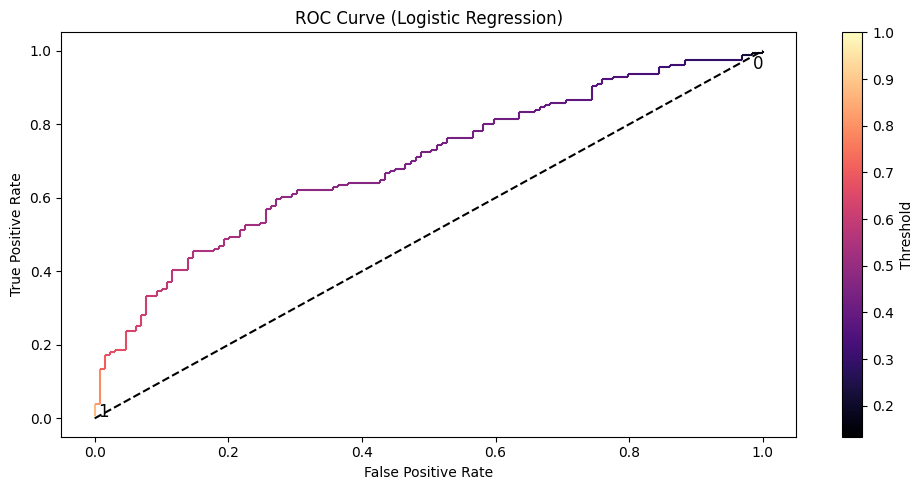

In [ ]:
from matplotlib import legend
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
fig, ax = plt.subplots(figsize=(10, 5))
points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, linewidth=1.5, cmap='magma')
lc.set_array(np.clip(thresholds, 0, 1))
ax.add_collection(lc)
ax.set(xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
ax.set_title("ROC Curve (Logistic Regression)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
cb = fig.colorbar(lc, ax=ax)
cb.set_label("Threshold")
ax.annotate("1", xy=(0.005, 0.005), fontsize=12)
ax.annotate("0", xy=(0.985, 0.95), fontsize=12)
ax.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.tight_layout()
plt.show()

In [ ]:
print("Test ROC AUC:", roc_auc_score(y_test, y_test_proba))

Test ROC AUC: 0.6933512224209899


### Default Random Forest

In [ ]:
rf_clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,          # let it grow; you can tune later
        min_samples_split=2,
        min_samples_leaf=1,
        n_jobs=-1,               # use all cores
        random_state=42,
        class_weight='balanced'  # optional, helps if classes imbalanced
    ))
])

In [ ]:
# Train
rf_clf.fit(X_train, y_train)

# Predict
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)

y_train_proba = rf_clf.predict_proba(X_train)[:, 1]
y_test_proba  = rf_clf.predict_proba(X_test)[:, 1]

rf_test_acc   = accuracy_score(y_test, rf_clf.predict(X_test))
rf_test_auc   = roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1])

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))


Train Accuracy: 1.0
Test Accuracy : 0.6280701754385964


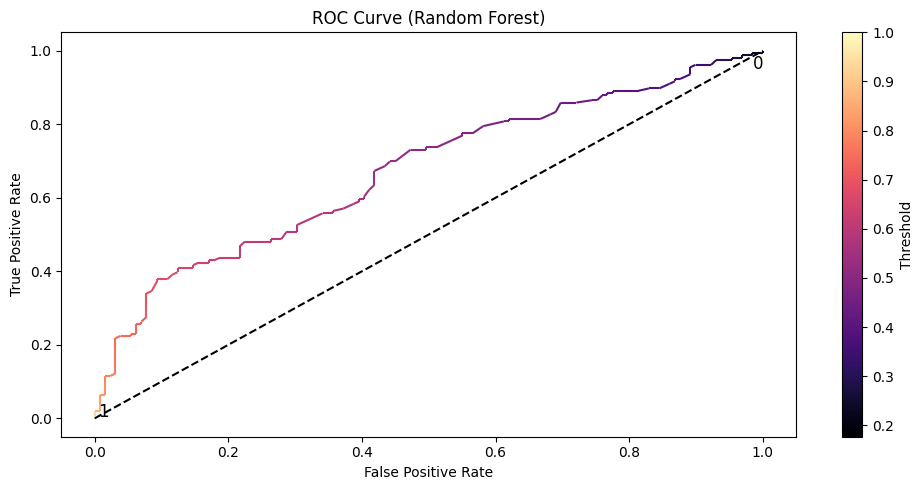

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
fig, ax = plt.subplots(figsize=(10, 5))
points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, linewidth=1.5, cmap='magma')
lc.set_array(np.clip(thresholds, 0, 1))
ax.add_collection(lc)
ax.set(xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
ax.set_title("ROC Curve (Random Forest)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
cb = fig.colorbar(lc, ax=ax)
cb.set_label("Threshold")
ax.annotate("1", xy=(0.005, 0.005), fontsize=12)
ax.annotate("0", xy=(0.985, 0.95), fontsize=12)
ax.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.tight_layout()
plt.show()

In [ ]:
print("Test ROC AUC  :", roc_auc_score(y_test, y_test_proba))

Test ROC AUC  : 0.6705923275690717


### Random Forest with Temporal Cross Validation

In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV

# 1. Reset index so we have clean 0..N-1 indices
X_train_reset = X_train.reset_index(drop=True).copy()
y_train_reset = y_train.reset_index(drop=True).copy()

# 2. Get seasons from the reset X
seasons = np.sort(X_train_reset["season"].unique())
print("Seasons in training:", seasons)

cv_folds = []

for i in range(1, len(seasons)):
    train_seasons = seasons[:i]
    test_season = seasons[i]

    season_vals = X_train_reset["season"].values

    train_idx = np.where(np.isin(season_vals, train_seasons))[0]
    test_idx  = np.where(season_vals == test_season)[0]

    print(f"Fold {i}: train seasons {train_seasons}, test season {test_season}, "
          f"train n={len(train_idx)}, test n={len(test_idx)}")

    cv_folds.append((train_idx, test_idx))

print(f"Number of temporal folds: {len(cv_folds)}")



Seasons in training: [2017 2018 2019 2020 2021 2022 2023]
Fold 1: train seasons [2017], test season 2018, train n=267, test n=265
Fold 2: train seasons [2017 2018], test season 2019, train n=532, test n=266
Fold 3: train seasons [2017 2018 2019], test season 2020, train n=798, test n=268
Fold 4: train seasons [2017 2018 2019 2020], test season 2021, train n=1066, test n=284
Fold 5: train seasons [2017 2018 2019 2020 2021], test season 2022, train n=1350, test n=282
Fold 6: train seasons [2017 2018 2019 2020 2021 2022], test season 2023, train n=1632, test n=285
Number of temporal folds: 6


In [ ]:
param_grid = {
    'model__max_depth': [6, 8, 10, None],
    'model__n_estimators': [200, 400]
}

grid = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv_folds,          # <- our temporal folds
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_reset, y_train_reset)

print("Best Params:", grid.best_params_)
print("Best CV ROC AUC (temporal):", grid.best_score_)


Fitting 6 folds for each of 8 candidates, totalling 48 fits
Best Params: {'model__max_depth': 6, 'model__n_estimators': 400}
Best CV ROC AUC (temporal): 0.6274987702833107


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

best_model = grid.best_estimator_

# Predictions on train (optional, just to see overfitting)
y_train_pred_cv  = best_model.predict(X_train)
y_train_proba_cv = best_model.predict_proba(X_train)[:, 1]

y_test_pred_cv  = best_model.predict(X_test)
y_test_proba_cv = best_model.predict_proba(X_test)[:, 1]

tuned_test_acc = accuracy_score(y_test, y_test_pred_cv)
tuned_test_auc = roc_auc_score(y_test, y_test_proba_cv)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_cv))
print("Test  Accuracy:", accuracy_score(y_test,  y_test_pred_cv))

print("Train ROC AUC:", roc_auc_score(y_train, y_train_proba_cv))
print("Test  ROC AUC:", roc_auc_score(y_test,  y_test_proba_cv))


Train Accuracy: 0.7730829420970265
Test  Accuracy: 0.6736842105263158
Train ROC AUC: 0.8586829215769431
Test  ROC AUC: 0.7162591930033791


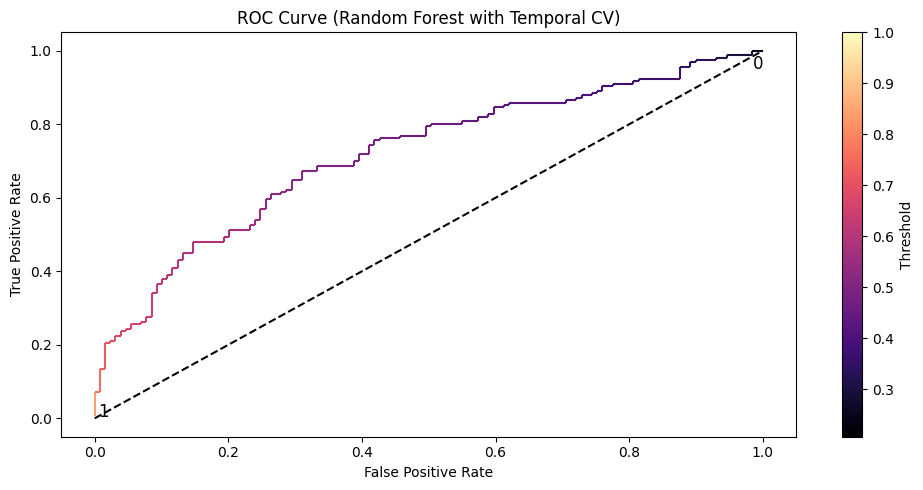

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_cv)
fig, ax = plt.subplots(figsize=(10, 5))
points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, linewidth=1.5, cmap='magma')
lc.set_array(np.clip(thresholds, 0, 1))
ax.add_collection(lc)
ax.set(xlim=(-0.05, 1.05), ylim=(-0.05, 1.05))
ax.set_title("ROC Curve (Random Forest with Temporal CV)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
cb = fig.colorbar(lc, ax=ax)
cb.set_label("Threshold")
ax.annotate("1", xy=(0.005, 0.005), fontsize=12)
ax.annotate("0", xy=(0.985, 0.95), fontsize=12)
ax.plot([0, 1], [0, 1], linestyle='--', color='black')
plt.tight_layout()
plt.show()

# Model Comparison

In [ ]:
from sklearn.metrics import f1_score

# Calculate F1 Scores
# For Majority Baseline, prediction is just the majority class
majority_class_pred = np.full_like(y_test, majority_class)
baseline_f1 = f1_score(y_test, majority_class_pred)

log_reg_f1 = f1_score(y_test, clf.predict(X_test))
rf_f1 = f1_score(y_test, rf_clf.predict(X_test))
tuned_rf_f1 = f1_score(y_test, best_model.predict(X_test))

results_df = pd.DataFrame({
    'Model': ['Majority Baseline', 'Logistic Regression', 'Default Random Forest', 'Tuned RF (GridSearch)'],
    'Test Accuracy': [baseline_acc, log_test_acc, rf_test_acc, tuned_test_acc],
    'Test ROC AUC':  [baseline_auc, log_test_auc, rf_test_auc, tuned_test_auc],
    'Test F1 Score': [baseline_f1, log_reg_f1, rf_f1, tuned_rf_f1]
})

results_df

,Model,Test Accuracy,Test ROC AUC,Test F1 Score
0,Majority Baseline,0.547368,0.500000,0.707483
1,Logistic Regression,0.645614,0.693351,0.640569
2,Default Random Forest,0.628070,0.670592,0.684524
3,Tuned RF (GridSearch),0.673684,0.716259,0.693069


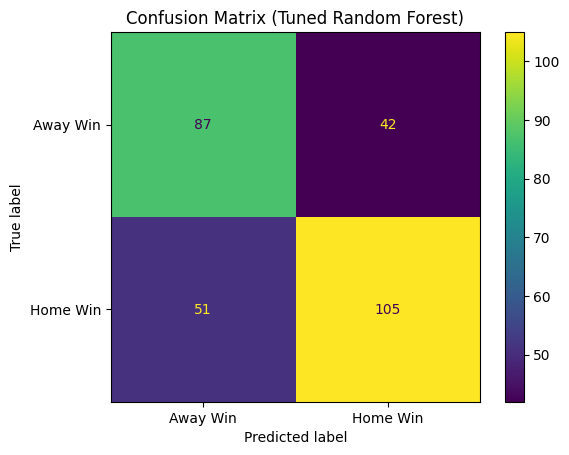

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define custom labels
custom_labels = ['Away Win', 'Home Win']

cm = confusion_matrix(y_test, y_test_pred_cv, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=custom_labels)
disp.plot()
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.show()

 # Financial Modeling

In [ ]:
import numpy as np
import pandas as pd

# Test data predictions
financial_df = test_df.copy()
financial_df["p_home"] = y_test_proba_cv
financial_df["p_away"] = 1 - financial_df["p_home"]

# Ground truth outcomes
financial_df["actual_home_win"] = y_test.values

# House margin candidates (overround)
H_values = np.arange(0.00, 0.21, 0.01)

# Average amount of money bet on a given NFL game on the
# leading sportsbook betting service
BASE_HANDLE = 31_600_000

ALPHA = 8  # Sensitivity of overround to demand tradeoff
FAVORITE_BIAS = 0.10  # 10% more weight to the favorite, 15% less to the dog

def handle_function(H):
    return BASE_HANDLE * max(0, 1 - ALPHA * (H - 0.05))

profit_results = []

for H in H_values:
    # Compute overround-adjusted "q" probabilities
    financial_df["q_home"] = financial_df["p_home"] * (1 + H)
    financial_df["q_away"] = financial_df["p_away"] * (1 + H)

    # Convert to decimal odds
    financial_df["odds_home"] = 1 / financial_df["q_home"]
    financial_df["odds_away"] = 1 / financial_df["q_away"]

    # Per-game total handle, given this H
    total_handle = handle_function(H)

    def game_profit(row):
        p_home = row["p_home"]
        p_away = row["p_away"]

        # --- Favorite bias on handle split ---
        if p_home >= p_away:
            # home is favorite
            w_home = p_home * (1 + FAVORITE_BIAS)
            w_away = p_away * (1 - FAVORITE_BIAS)
        else:
            # away is favorite
            w_home = p_home * (1 - FAVORITE_BIAS)
            w_away = p_away * (1 + FAVORITE_BIAS)

        # normalize so weights sum to 1
        w_sum = w_home + w_away
        share_home = w_home / w_sum
        share_away = w_away / w_sum

        x_home = total_handle * share_home
        x_away = total_handle * share_away

        intake = x_home + x_away  # ≈ total_handle

        if row["actual_home_win"] == 1:
            payout = row["odds_home"] * x_home
        else:
            payout = row["odds_away"] * x_away

        return intake - payout

    financial_df["profit_H"] = financial_df.apply(game_profit, axis=1)

    total_profit = financial_df["profit_H"].sum()

    profit_results.append({
        "H": H,
        "Total Profit": total_profit,
        "Average per Game": total_profit / len(financial_df),
        "Handle Used": total_handle
    })

profit_df = pd.DataFrame(profit_results)
profit_df


,H,Total Profit,Average per Game,Handle Used
0,0.00,-1.575729e+08,-5.528872e+05,44240000.0
1,0.01,-2.939554e+07,-1.031423e+05,41712000.0
2,0.02,8.214144e+07,2.882156e+05,39184000.0
3,0.03,1.775227e+08,6.228868e+05,36656000.0
4,0.04,2.572144e+08,9.025067e+05,34128000.0
5,0.05,3.216647e+08,1.128648e+06,31600000.0
6,0.06,3.713050e+08,1.302825e+06,29072000.0
7,0.07,4.065505e+08,1.426493e+06,26544000.0
8,0.08,4.278012e+08,1.501057e+06,24016000.0
9,0.09,4.354420e+08,1.527867e+06,21488000.0


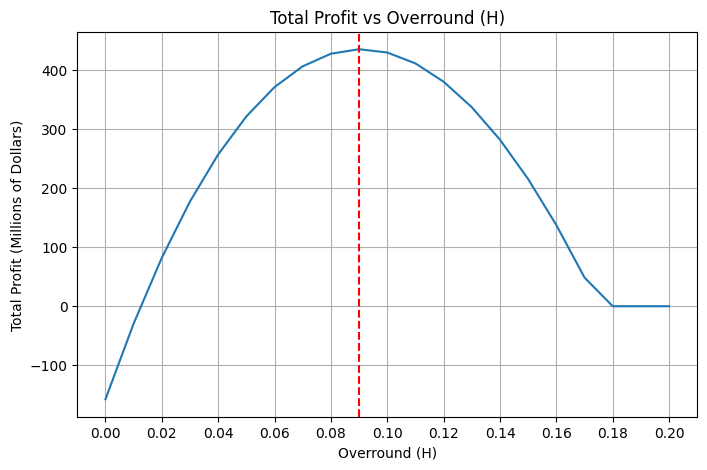

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Convert profit to millions
profit_millions = profit_df["Total Profit"] / 1_000_000

# Plot
plt.plot(profit_df["H"], profit_millions)

# Labeling
plt.xlabel("Overround (H)")
plt.ylabel("Total Profit (Millions of Dollars)")
plt.title("Total Profit vs Overround (H)")
plt.grid(True)

plt.axvline(x=0.09, color='red', linestyle='--', linewidth=1.5)

# Set H ticks every 0.02
h_ticks = np.arange(0.0, 0.21, 0.02)
plt.xticks(h_ticks)

plt.show()

## Hopefully Final???

In [ ]:
import numpy as np
import pandas as pd

# -----------------------------
# Setup
# -----------------------------
financial_df = test_df.copy()

# ML model probabilities
financial_df["p_home_ml"] = y_test_proba_cv
financial_df["p_away_ml"] = 1 - financial_df["p_home_ml"]

# Majority baseline probabilities
BASE_P = 0.54   # home win probability
financial_df["p_home_base"] = BASE_P
financial_df["p_away_base"] = 1 - BASE_P

# Actual outcomes
financial_df["actual_home_win"] = y_test.values

# Overround values
H_values = np.arange(0.00, 0.31, 0.01)

# Fixed average handle per NFL game
BASE_HANDLE = 1_000_000
ALPHA = 8   # demand sensitivity for handle shrink

def handle_function(H):
    return BASE_HANDLE * max(0, 1 - ALPHA * (H - 0.05))

# Function to evaluate profit for a given probability source
def evaluate_strategy(p_home_col, p_away_col):
    results = []

    for H in H_values:
        df = financial_df.copy()

        # Compute q (inflated probs)
        df["q_home"] = df[p_home_col] * (1 + H)
        df["q_away"] = df[p_away_col] * (1 + H)

        # Convert to decimal odds
        df["odds_home"] = 1 / df["q_home"]
        df["odds_away"] = 1 / df["q_away"]

        # Handle per game at this H
        total_handle = handle_function(H)

        def game_profit(row):
            # EVEN HANDLE SPLIT
            x_home = total_handle * 0.5
            x_away = total_handle * 0.5

            intake = x_home + x_away

            if row["actual_home_win"] == 1:
                payout = row["odds_home"] * x_home
            else:
                payout = row["odds_away"] * x_away

            return intake - payout

        df["profit_H"] = df.apply(game_profit, axis=1)

        total_profit = df["profit_H"].sum()

        results.append({
            "H": H,
            "Total Profit": total_profit,
            "Average per Game": total_profit / len(df),
            "Handle Used": total_handle
        })

    return pd.DataFrame(results)


# Run both strategies
profit_ml_df   = evaluate_strategy("p_home_ml",   "p_away_ml")
profit_base_df = evaluate_strategy("p_home_base", "p_away_base")

display(profit_ml_df)

profit_base_df


,H,Total Profit,Average per Game,Handle Used
0,0.00,1.586546e+07,55668.294540,1400000.0
1,0.01,1.853551e+07,65036.880335,1320000.0
2,0.02,2.070615e+07,72653.140917,1240000.0
3,0.03,2.239191e+07,78568.114887,1160000.0
4,0.04,2.360680e+07,82830.877818,1080000.0
5,0.05,2.436426e+07,85488.635742,1000000.0
6,0.06,2.467724e+07,86586.813327,920000.0
7,0.07,2.455820e+07,86169.137125,840000.0
8,0.08,2.401915e+07,84277.714187,760000.0
9,0.09,2.307164e+07,80953.106348,680000.0


,H,Total Profit,Average per Game,Handle Used
0,0.00,4.734300e+05,1661.157725,1400000.0
1,0.01,4.166710e+06,14620.034086,1320000.0
2,0.02,7.340513e+06,25756.187380,1240000.0
3,0.03,1.000997e+07,35122.706631,1160000.0
4,0.04,1.218963e+07,42770.638972,1080000.0
5,0.05,1.389349e+07,48749.086888,1000000.0
6,0.06,1.513501e+07,53105.299937,920000.0
7,0.07,1.592716e+07,55884.761341,840000.0
8,0.08,1.628241e+07,57131.269756,760000.0
9,0.09,1.621280e+07,56887.016549,680000.0


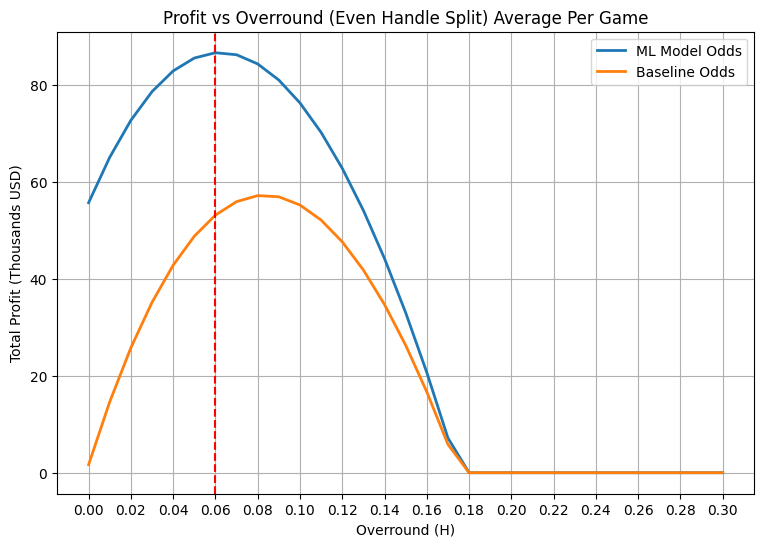

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

# Convert to millions
ml_millions   = profit_ml_df["Average per Game"] / 1_000
base_millions = profit_base_df["Average per Game"] / 1_000

plt.plot(profit_ml_df["H"], ml_millions, label="ML Model Odds", linewidth=2)
plt.plot(profit_base_df["H"], base_millions, label="Baseline Odds", linewidth=2)

# Dotted reference line at H = 0.07
plt.axvline(x=0.06, color="red", linestyle="--", linewidth=1.5)

plt.xlabel("Overround (H)")
plt.ylabel("Total Profit (Thousands USD)")
plt.title("Profit vs Overround (Even Handle Split) Average Per Game")
plt.grid(True)
plt.legend()

# Tick marks in increments of 0.02
plt.xticks(np.arange(0.0, 0.31, 0.02))

plt.show()


In [ ]:
import numpy as np
import pandas as pd

#------------------------------------------------------------------
# Assumptions: you already have something like this defined earlier:
# - test_df
# - y_test_proba_cv (model probs for home win)
# - y_test (0/1 actual home win)
#------------------------------------------------------------------

# Build a working df with model + baseline probabilities
financial_df = test_df.copy()

# Model probabilities
financial_df["p_home_ml"] = y_test_proba_cv
financial_df["p_away_ml"] = 1 - financial_df["p_home_ml"]

# Baseline probabilities (majority home win rate, e.g. 0.54)
BASE_P = y_train.mean() if "y_train" in globals() else 0.54
financial_df["p_home_base"] = BASE_P
financial_df["p_away_base"] = 1 - BASE_P

# Ground truth
financial_df["actual_home_win"] = y_test.values


# 1. Identify high-confidence games
HIGH_CONF = 0.75  # "confident" means |p - 0.5| >= 0.25

financial_df["high_conf"] = (
    (financial_df["p_home_ml"] >= HIGH_CONF) |
    (financial_df["p_home_ml"] <= (1 - HIGH_CONF))
)

high_conf_df = financial_df[financial_df["high_conf"]].copy()
print("Number of high-confidence games:", len(high_conf_df))


# 2. Shared handle function / parameters
H_values = np.arange(0.00, 0.21, 0.01)   # if you want the whole curve
H_STAR = 0.06                            # pick a focal H to report

BASE_HANDLE = 31_600_000
ALPHA = 8

def handle_function(H):
    return BASE_HANDLE * max(0, 1 - ALPHA * (H - 0.05))


# 3. Helper to compute profit on a GIVEN DF + probs (even 50/50 handle split)
def profit_for_subset(df_subset, p_home_col, p_away_col, H):
    df = df_subset.copy()

    # Overround-adjusted probabilities
    df["q_home"] = df[p_home_col] * (1 + H)
    df["q_away"] = df[p_away_col] * (1 + H)

    # Decimal odds
    df["odds_home"] = 1 / df["q_home"]
    df["odds_away"] = 1 / df["q_away"]

    total_handle = handle_function(H)

    def game_profit(row):
        # Even 50/50 split for this experiment
        x_home = total_handle * 0.5
        x_away = total_handle * 0.5

        intake = x_home + x_away

        if row["actual_home_win"] == 1:
            payout = row["odds_home"] * x_home
        else:
            payout = row["odds_away"] * x_away

        return intake - payout

    df["profit_H"] = df.apply(game_profit, axis=1)

    total_profit = df["profit_H"].sum()
    avg_per_game = total_profit / len(df)

    return total_profit, avg_per_game

# 4. Profit on high-confidence games at a single H
ml_profit_total, ml_profit_avg = profit_for_subset(
    high_conf_df, "p_home_ml", "p_away_ml", H_STAR
)

base_profit_total, base_profit_avg = profit_for_subset(
    high_conf_df, "p_home_base", "p_away_base", H_STAR
)

print(f"\n=== High-confidence games only (H = {H_STAR:.2f}) ===")
print(f"ML odds   - Total Profit: {ml_profit_total:,.0f},  Avg per game: {ml_profit_avg:,.2f}")
print(f"Baseline  - Total Profit: {base_profit_total:,.0f},  Avg per game: {base_profit_avg:,.2f}")


# 5. (Optional) Profit vs H curve for high-confidence games
results = []
for H in H_values:
    ml_tot, ml_avg = profit_for_subset(high_conf_df, "p_home_ml", "p_away_ml", H)
    base_tot, base_avg = profit_for_subset(high_conf_df, "p_home_base", "p_away_base", H)
    results.append({
        "H": H,
        "ML_Total_Profit": ml_tot,
        "ML_Avg_Game": ml_avg,
        "Base_Total_Profit": base_tot,
        "Base_Avg_Game": base_avg
    })

profit_highconf_df = pd.DataFrame(results)
profit_highconf_df.head()


Number of high-confidence games: 16

=== High-confidence games only (H = 0.06) ===
ML odds   - Total Profit: 149,382,667,  Avg per game: 9,336,416.69
Baseline  - Total Profit: 48,920,761,  Avg per game: 3,057,547.55


,H,ML_Total_Profit,ML_Avg_Game,Base_Total_Profit,Base_Avg_Game
0,0.00,1.984903e+08,1.240565e+07,3.644091e+07,2.277557e+06
1,0.01,1.919029e+08,1.199393e+07,4.062623e+07,2.539140e+06
2,0.02,1.846516e+08,1.154072e+07,4.393639e+07,2.746024e+06
3,0.03,1.767556e+08,1.104723e+07,4.639687e+07,2.899805e+06
4,0.04,1.682337e+08,1.051461e+07,4.803219e+07,3.002012e+06


In [ ]:
# LOW CONFIDENCE GAMES: 0.50 < p_home_ml < 0.75
# (i.e., games where the model is unsure or only mildly leaning)

low_conf_df = financial_df[
    (financial_df["p_home_ml"] > 0.50) &
    (financial_df["p_home_ml"] < 0.75)
].copy()

print("Number of low-confidence games:", len(low_conf_df))

# Use the same profit_for_subset function already defined:

# profit_for_subset(df_subset, p_home_col, p_away_col, H)


# Choose an H value to report summary profit (use 0.09 or whatever your “optimal” is)
H_STAR = 0.06

# ML odds profit on low-confidence
ml_low_total, ml_low_avg = profit_for_subset(
    low_conf_df, "p_home_ml", "p_away_ml", H_STAR
)

# Baseline odds profit on low-confidence
base_low_total, base_low_avg = profit_for_subset(
    low_conf_df, "p_home_base", "p_away_base", H_STAR
)

print(f"\n=== Low-confidence games only (H = {H_STAR:.2f}) ===")
print(f"ML odds   - Total Profit: {ml_low_total:,.0f},  Avg per game: {ml_low_avg:,.2f}")
print(f"Baseline  - Total Profit: {base_low_total:,.0f},  Avg per game: {base_low_avg:,.2f}")

# Optional: Profit vs H curve for low-confidence games
low_conf_results = []

for H in H_values:
    ml_tot, ml_avg = profit_for_subset(low_conf_df, "p_home_ml", "p_away_ml", H)
    base_tot, base_avg = profit_for_subset(low_conf_df, "p_home_base", "p_away_base", H)
    low_conf_results.append({
        "H": H,
        "ML_Total_Profit": ml_tot,
        "ML_Avg_Game": ml_avg,
        "Base_Total_Profit": base_tot,
        "Base_Avg_Game": base_avg
    })

profit_lowconf_df = pd.DataFrame(low_conf_results)
profit_lowconf_df.head()


Number of low-confidence games: 133

=== Low-confidence games only (H = 0.06) ===
ML odds   - Total Profit: 394,147,480,  Avg per game: 2,963,514.89
Baseline  - Total Profit: 320,826,529,  Avg per game: 2,412,229.54


,H,ML_Total_Profit,ML_Avg_Game,Base_Total_Profit,Base_Avg_Game
0,0.00,2.827418e+08,2.125878e+06,1.644719e+08,1.236631e+06
1,0.01,3.188734e+08,2.397544e+06,2.084658e+08,1.567412e+06
2,0.02,3.477038e+08,2.614315e+06,2.450045e+08,1.842139e+06
3,0.03,3.694459e+08,2.777788e+06,2.743050e+08,2.062444e+06
4,0.04,3.843039e+08,2.889503e+06,2.965763e+08,2.229897e+06


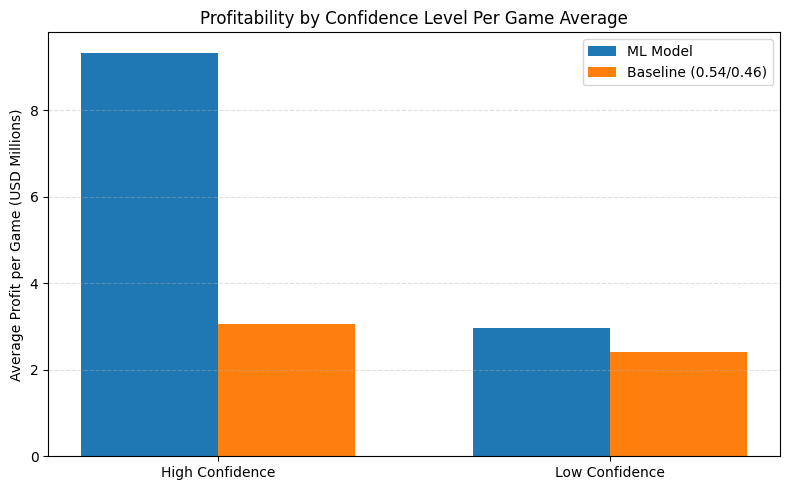

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Labels
groups = ["High Confidence", "Low Confidence"]
ml_values = [ml_profit_avg / 1_000_000 , ml_low_avg / 1_000_000]
base_values = [base_profit_avg / 1_000_000, base_low_avg / 1_000_000]

x = np.arange(len(groups))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, ml_values, width, label="ML Model", color="#1f77b4")
plt.bar(x + width/2, base_values, width, label="Baseline (0.54/0.46)", color="#ff7f0e")

plt.xticks(x, groups)
plt.ylabel("Average Profit per Game (USD Millions)")
plt.title("Profitability by Confidence Level Per Game Average")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# Confidence from 0.5 to 0.75 (exclusive of 0.75)
range_50_75 = df_results[(df_results['confidence'] >= 0.5) & (df_results['confidence'] < 0.75)]

if not range_50_75.empty:
    accuracy_50_75 = accuracy_score(range_50_75['true_label'], (range_50_75['probability'] >= 0.5).astype(int))
else:
    accuracy_50_75 = np.nan # No predictions in this range

# Confidence from 0.8 and above
range_80_plus = df_results[df_results['confidence'] >= 0.8]

if not range_80_plus.empty:
    accuracy_80_plus = accuracy_score(range_80_plus['true_label'], (range_80_plus['probability'] >= 0.5).astype(int))
else:
    accuracy_80_plus = np.nan # No predictions in this range

print(f"Test Accuracy for Tuned RF Model (Confidence 0.50 - 0.75): {accuracy_50_75:.4f}")
print(f"Test Accuracy for Tuned RF Model (Confidence 0.80 and above): {accuracy_80_plus:.4f}")


Test Accuracy for Tuned RF Model (Confidence 0.50 - 0.75): 0.6580
Test Accuracy for Tuned RF Model (Confidence 0.80 and above): 1.0000
